# Sports Performance Analysis System


## Load Dataset



In [ ]:
from google.colab import files

uploaded = files.upload()

Saving player_profiles.csv to player_profiles.csv


In [ ]:
import pandas as pd

players = pd.read_csv("player_profiles.csv", low_memory=False)

## Data Understanding

In [ ]:
players.head()

,player_id,player_slug,player_name,player_image_url,name_in_home_country,date_of_birth,place_of_birth,country_of_birth,height,citizenship,...,on_loan_from_club_id,on_loan_from_club_name,contract_there_expires,second_club_url,second_club_name,third_club_url,third_club_name,fourth_club_url,fourth_club_name,date_of_death
0,1,silvio-adzic,Silvio Adzic (1),https://img.a.transfermarkt.technology/portrai...,NaN,1980-09-23,Grünstadt,Germany,0.0,Germany,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100011,everton-silva,Éverton Silva (100011),https://img.a.transfermarkt.technology/portrai...,Éverton José Modesto da Silva,1988-08-04,São João de Meriti,Brazil,171.0,Brazil,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10,miroslav-klose,Miroslav Klose (10),https://img.a.transfermarkt.technology/portrai...,Miroslav Josef Klose,1978-06-09,Opole,Germany,184.0,Germany,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,john-thompson,John Thompson (10001),https://img.a.transfermarkt.technology/portrai...,John Paul Thompson,1981-10-12,Dublin,Ireland,183.0,Ireland,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100001,carlos-auzqui,Carlos Auzqui (100001),https://img.a.transfermarkt.technology/portrai...,Carlos Daniel Auzqui,1991-03-16,Longchamps,Argentina,180.0,Argentina,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
players.shape

(92671, 34)

In [ ]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92671 entries, 0 to 92670
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   player_id                        92671 non-null  int64  
 1   player_slug                      92671 non-null  object 
 2   player_name                      92151 non-null  object 
 3   player_image_url                 92671 non-null  object 
 4   name_in_home_country             49653 non-null  object 
 5   date_of_birth                    91665 non-null  object 
 6   place_of_birth                   76038 non-null  object 
 7   country_of_birth                 76026 non-null  object 
 8   height                           92667 non-null  float64
 9   citizenship                      92614 non-null  object 
 10  is_eu                            92671 non-null  bool   
 11  position                         92669 non-null  object 
 12  main_position     

In [ ]:
players.columns.tolist()

['player_id',
 'player_slug',
 'player_name',
 'player_image_url',
 'name_in_home_country',
 'date_of_birth',
 'place_of_birth',
 'country_of_birth',
 'height',
 'citizenship',
 'is_eu',
 'position',
 'main_position',
 'foot',
 'current_club_id',
 'current_club_name',
 'joined',
 'contract_expires',
 'outfitter',
 'social_media_url',
 'player_agent_id',
 'player_agent_name',
 'contract_option',
 'date_of_last_contract_extension',
 'on_loan_from_club_id',
 'on_loan_from_club_name',
 'contract_there_expires',
 'second_club_url',
 'second_club_name',
 'third_club_url',
 'third_club_name',
 'fourth_club_url',
 'fourth_club_name',
 'date_of_death']

## Data Cleaning


In [ ]:
players_clean = players[[
    'player_id',
    'player_name',
    'date_of_birth',
    'country_of_birth',
    'citizenship',
    'height',
    'position',
    'main_position',
    'foot',
    'current_club_id',
    'current_club_name',
    'joined',
    'contract_expires'
]]

In [ ]:
players_clean.head()

,player_id,player_name,date_of_birth,country_of_birth,citizenship,height,position,main_position,foot,current_club_id,current_club_name,joined,contract_expires
0,1,Silvio Adzic (1),1980-09-23,Germany,Germany,0.0,Attack - Right Winger,Attack,NaN,123,Retired,2017-07-01,NaN
1,100011,Éverton Silva (100011),1988-08-04,Brazil,Brazil,171.0,Defender - Right-Back,Defender,right,515,Without Club,2025-03-01,NaN
2,10,Miroslav Klose (10),1978-06-09,Germany,Germany,184.0,Attack - Centre-Forward,Attack,right,123,Retired,2016-07-01,NaN
3,10001,John Thompson (10001),1981-10-12,Ireland,Ireland,183.0,Defender - Right-Back,Defender,both,123,Retired,2013-07-01,NaN
4,100001,Carlos Auzqui (100001),1991-03-16,Argentina,Argentina,180.0,Attack - Right Winger,Attack,right,14554,Club Atlético Tucumán,2025-01-30,2025-12-31


In [ ]:
players_clean.duplicated().sum()

np.int64(0)

In [ ]:
players_clean.isnull().sum()

,0
player_id,0
player_name,520
date_of_birth,1006
country_of_birth,16645
citizenship,57
height,4
position,2
main_position,2
foot,23488
current_club_id,0


In [ ]:
players_clean = players_clean.dropna(
    subset=['player_name', 'date_of_birth', 'position', 'main_position']
)

In [ ]:
players_clean['citizenship'] = players_clean['citizenship'].fillna('Unknown')

In [ ]:
players_clean['foot'] = players_clean['foot'].fillna('Unknown')

In [ ]:
players_clean['height'] = players_clean['height'].fillna(
    players_clean['height'].mean()
)

In [ ]:
players_clean.isnull().sum()

,0
player_id,0
player_name,0
date_of_birth,0
country_of_birth,15781
citizenship,0
height,0
position,0
main_position,0
foot,0
current_club_id,0


In [ ]:
players_clean['date_of_birth'] = pd.to_datetime(
    players_clean['date_of_birth'],
    errors='coerce'
)

players_clean['joined'] = pd.to_datetime(
    players_clean['joined'],
    errors='coerce'
)

players_clean['contract_expires'] = pd.to_datetime(
    players_clean['contract_expires'],
    errors='coerce'
)

In [ ]:
today = pd.Timestamp.today()

players_clean['age'] = (
    (today - players_clean['date_of_birth']).dt.days // 365
)

In [ ]:
players_clean.head()

,player_id,player_name,date_of_birth,country_of_birth,citizenship,height,position,main_position,foot,current_club_id,current_club_name,joined,contract_expires,age
0,1,Silvio Adzic (1),1980-09-23,Germany,Germany,0.0,Attack - Right Winger,Attack,Unknown,123,Retired,2017-07-01,NaT,45
1,100011,Éverton Silva (100011),1988-08-04,Brazil,Brazil,171.0,Defender - Right-Back,Defender,right,515,Without Club,2025-03-01,NaT,37
2,10,Miroslav Klose (10),1978-06-09,Germany,Germany,184.0,Attack - Centre-Forward,Attack,right,123,Retired,2016-07-01,NaT,48
3,10001,John Thompson (10001),1981-10-12,Ireland,Ireland,183.0,Defender - Right-Back,Defender,both,123,Retired,2013-07-01,NaT,44
4,100001,Carlos Auzqui (100001),1991-03-16,Argentina,Argentina,180.0,Attack - Right Winger,Attack,right,14554,Club Atlético Tucumán,2025-01-30,2025-12-31,35


In [ ]:
players_clean['height'] = players_clean['height'].replace(0, pd.NA)

players_clean['height'] = players_clean['height'].fillna(
    players_clean['height'].mean()
)

/tmp/ipykernel_727/1127758909.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  players_clean['height'] = players_clean['height'].fillna(


In [ ]:
players_clean['height'].min()

145.75828853538124

## Save Clean Dataset

In [ ]:
players_clean.to_csv("players_clean.csv", index=False)

# Player Performances

## Load Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving player_performances.csv to player_performances.csv


In [ ]:
performances = pd.read_csv("player_performances.csv", low_memory=False)

## Data Understanding

In [ ]:
performances.head()

,player_id,season_name,competition_id,competition_name,team_id,team_name,nb_in_group,nb_on_pitch,goals,assists,own_goals,subed_in,subed_out,yellow_cards,second_yellow_cards,direct_red_cards,penalty_goals,minutes_played,goals_conceded,clean_sheets
0,1,08/09,OBLG,NOFV-Oberliga Süd,4825,FC Eilenburg,9,9,0.0,0,0,0,2,0,0,1,0,NaN,0,0
1,1,07/08,RS,Regionalliga Süd,1526,FSV Ludwigshafen Oggersheim,22,22,1.0,0,0,3,8,1,0,0,0,1580.0,0,0
2,1,06/07,L2,2. Bundesliga,996,TuS Koblenz,10,4,0.0,0,0,4,0,0,0,0,0,NaN,0,0
3,1,06/07,DFB,DFB-Pokal,996,TuS Koblenz,1,0,0.0,0,0,0,0,0,0,0,0,NaN,0,0
4,1,05/06,L2,2. Bundesliga,66,SpVgg Unterhaching,26,14,1.0,1,0,12,1,1,0,0,0,388.0,0,0


In [ ]:
performances.shape

(1878719, 20)

In [ ]:
performances.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1878719 entries, 0 to 1878718
Data columns (total 20 columns):
 #   Column               Dtype  
---  ------               -----  
 0   player_id            int64  
 1   season_name          object 
 2   competition_id       object 
 3   competition_name     object 
 4   team_id              int64  
 5   team_name            object 
 6   nb_in_group          int64  
 7   nb_on_pitch          int64  
 8   goals                float64
 9   assists              int64  
 10  own_goals            int64  
 11  subed_in             int64  
 12  subed_out            int64  
 13  yellow_cards         int64  
 14  second_yellow_cards  int64  
 15  direct_red_cards     int64  
 16  penalty_goals        int64  
 17  minutes_played       float64
 18  goals_conceded       int64  
 19  clean_sheets         int64  
dtypes: float64(2), int64(14), object(4)
memory usage: 286.7+ MB


In [ ]:
performances.columns.tolist()

['player_id',
 'season_name',
 'competition_id',
 'competition_name',
 'team_id',
 'team_name',
 'nb_in_group',
 'nb_on_pitch',
 'goals',
 'assists',
 'own_goals',
 'subed_in',
 'subed_out',
 'yellow_cards',
 'second_yellow_cards',
 'direct_red_cards',
 'penalty_goals',
 'minutes_played',
 'goals_conceded',
 'clean_sheets']

In [ ]:
performances.isnull().sum()

,0
player_id,0
season_name,0
competition_id,0
competition_name,0
team_id,0
team_name,0
nb_in_group,0
nb_on_pitch,0
goals,138202
assists,0


In [ ]:
performances['goals'] = performances['goals'].fillna(0)

performances['minutes_played'] = performances['minutes_played'].fillna(0)

## Check Duplicates

In [ ]:
performances.duplicated().sum()

np.int64(0)

In [ ]:
performances['goals'] = performances['goals'].fillna(0)
performances['minutes_played'] = performances['minutes_played'].fillna(0)

In [ ]:
performances.isnull().sum()

,0
player_id,0
season_name,0
competition_id,0
competition_name,0
team_id,0
team_name,0
nb_in_group,0
nb_on_pitch,0
goals,0
assists,0


## Save Clean Dataset

In [ ]:
performances.to_csv("performances_clean.csv", index=False)

# Team Details

## Load Data

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving team_details.csv to team_details.csv


In [ ]:
teams = pd.read_csv("team_details.csv", low_memory=False)

## Data Understanding

In [ ]:
teams.head()

,club_id,club_slug,club_name,logo_url,country_name,season_id,competition_id,competition_slug,competition_name,club_division,source_url,_last_modified_at
0,100335,cd-mafra-sub-23,CD Mafra U23 (100335),https://tmssl.akamaized.net//images/wappen/hea...,Portugal,2023,NaN,NaN,NaN,NaN,https://www.transfermarkt.com/cd-mafra-sub-23/...,2025-09-11 20:20:19
1,100431,napoli-under-18,Napoli Under 18 (100431),https://tmssl.akamaized.net//images/wappen/hea...,Italy,2021,ITJ7,campionato-nazionale-under-18,Campionato Under 18,Campionato Under 18,https://www.transfermarkt.com/napoli-under-18/...,2025-09-13 09:55:03
2,101416,venezia-under-18,Venezia Under 18 (101416),https://tmssl.akamaized.net//images/wappen/hea...,Italy,2022,NaN,NaN,NaN,NaN,https://www.transfermarkt.com/venezia-under-18...,2025-09-13 09:37:05
3,100461,lecce-under-18,Lecce Under 18 (100461),https://tmssl.akamaized.net//images/wappen/hea...,Italy,2015,ITJ7,campionato-nazionale-under-18,Campionato Under 18,Campionato Under 18,https://www.transfermarkt.com/lecce-under-18/s...,2025-09-13 09:52:59
4,10010,esporte-clube-bahia,Esporte Clube Bahia (10010),https://tmssl.akamaized.net//images/wappen/hea...,Brazil,2006,BRA1,campeonato-brasileiro-serie-a,Campeonato Brasileiro Série A,Campeonato Brasileiro Série A,https://www.transfermarkt.com/esporte-clube-ba...,2025-09-13 11:59:31


In [ ]:
teams.shape

(2175, 12)

In [ ]:
teams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2175 entries, 0 to 2174
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   club_id            2175 non-null   int64 
 1   club_slug          2175 non-null   object
 2   club_name          2175 non-null   object
 3   logo_url           2175 non-null   object
 4   country_name       2175 non-null   object
 5   season_id          2175 non-null   int64 
 6   competition_id     1669 non-null   object
 7   competition_slug   1669 non-null   object
 8   competition_name   1669 non-null   object
 9   club_division      1669 non-null   object
 10  source_url         2175 non-null   object
 11  _last_modified_at  2175 non-null   object
dtypes: int64(2), object(10)
memory usage: 204.0+ KB


In [ ]:
teams.columns.tolist()

['club_id',
 'club_slug',
 'club_name',
 'logo_url',
 'country_name',
 'season_id',
 'competition_id',
 'competition_slug',
 'competition_name',
 'club_division',
 'source_url',
 '_last_modified_at']

In [ ]:
teams.isnull().sum()

,0
club_id,0
club_slug,0
club_name,0
logo_url,0
country_name,0
season_id,0
competition_id,506
competition_slug,506
competition_name,506
club_division,506


In [ ]:
teams.duplicated().sum()

np.int64(0)

## Data Cleaning

In [ ]:
teams_clean = teams[[
    'club_id',
    'club_name',
    'country_name',
    'season_id',
    'competition_name',
    'club_division'
]].copy()

In [ ]:
teams_clean['competition_name'] = teams_clean['competition_name'].fillna('Unknown')

teams_clean['club_division'] = teams_clean['club_division'].fillna('Unknown')

In [ ]:
teams_clean.isnull().sum()

,0
club_id,0
club_name,0
country_name,0
season_id,0
competition_name,0
club_division,0


## Save Clean Dataset

In [ ]:
teams_clean.to_csv("teams_clean.csv", index=False)

# Player Market Value

## Load Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving player_market_value.csv to player_market_value.csv


In [ ]:
market_value = pd.read_csv("player_market_value.csv", low_memory=False)

## Data Understanding

In [ ]:
market_value.head()

,player_id,date_unix,value
0,1000135,2023-12-19,100000.0
1,1000135,2024-06-23,100000.0
2,10,2005-01-06,9000000.0
3,10,2008-06-03,20000000.0
4,10,2009-08-29,12000000.0


In [ ]:
market_value.shape

(901429, 3)

In [ ]:
market_value.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 901429 entries, 0 to 901428
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   player_id  901429 non-null  int64  
 1   date_unix  901429 non-null  object 
 2   value      901429 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 20.6+ MB


In [ ]:
market_value.columns.tolist()

['player_id', 'date_unix', 'value']

In [ ]:
market_value.isnull().sum()

,0
player_id,0
date_unix,0
value,0


In [ ]:
market_value.duplicated().sum()

np.int64(0)

## Data Cleaning


In [ ]:
market_value['date_unix'] = pd.to_datetime(
    market_value['date_unix'],
    errors='coerce'
)

In [ ]:
market_value = market_value.rename(columns={
    'date_unix': 'market_value_date',
    'value': 'market_value'
})

## Save Clean Dataset

In [ ]:
market_value.to_csv("market_value_clean.csv", index=False)

# Player Injuries

## Load Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving player_injuries.csv to player_injuries.csv


In [ ]:
injuries = pd.read_csv("player_injuries.csv", low_memory=False)

## Data Understanding

In [ ]:
injuries.head()

,player_id,season_name,injury_reason,from_date,end_date,days_missed,games_missed
0,10,15/16,Hand injury,2016-04-19,2016-04-29,11.0,2
1,10,15/16,Thigh problems,2015-12-18,2015-12-31,14.0,1
2,10,15/16,Capsular injury,2015-11-11,2015-11-21,11.0,0
3,10,15/16,Rest,2015-11-04,2015-11-06,3.0,1
4,10,15/16,Hamstring injury,2015-08-20,2015-10-08,50.0,10


In [ ]:
injuries.shape

(143195, 7)

In [ ]:
injuries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143195 entries, 0 to 143194
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   player_id      143195 non-null  int64  
 1   season_name    143195 non-null  object 
 2   injury_reason  143195 non-null  object 
 3   from_date      143173 non-null  object 
 4   end_date       141672 non-null  object 
 5   days_missed    143173 non-null  float64
 6   games_missed   143195 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 7.6+ MB


In [ ]:
injuries.isnull().sum()

,0
player_id,0
season_name,0
injury_reason,0
from_date,22
end_date,1523
days_missed,22
games_missed,0


In [ ]:
injuries.duplicated().sum()

np.int64(111)

## Data Cleaning

In [ ]:
injuries = injuries.drop_duplicates()

In [ ]:
injuries.duplicated().sum()

np.int64(0)

In [ ]:
injuries['from_date'] = pd.to_datetime(
    injuries['from_date'],
    errors='coerce'
)

injuries['end_date'] = pd.to_datetime(
    injuries['end_date'],
    errors='coerce'
)

In [ ]:
injuries['days_missed'] = injuries['days_missed'].fillna(0)

In [ ]:
injuries.isnull().sum()

,0
player_id,0
season_name,0
injury_reason,0
from_date,22
end_date,1521
days_missed,0
games_missed,0


## Save Clean Dataset

In [ ]:
injuries.to_csv("injuries_clean.csv", index=False)

# Transfer History

## Load Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving transfer_history.csv to transfer_history.csv


In [ ]:
transfers = pd.read_csv("transfer_history.csv", low_memory=False)

## Data Understanding

In [ ]:
transfers.head()

,player_id,season_name,transfer_date,from_team_id,from_team_name,to_team_id,to_team_name,transfer_type,value_at_transfer,transfer_fee
0,1000,11/12,2011-07-01,3496,A. Ludwigshafen,123,Retired,Transfer,200000,0
1,1000,10/11,2011-01-01,85,W. Mannheim,3496,A. Ludwigshafen,Transfer,200000,0
2,1000,07/08,2007-07-01,1,Saarbrücken,85,W. Mannheim,Transfer,125000,0
3,1000,00/01,2000-07-01,726,FK Pirmasens,1,Saarbrücken,Transfer,0,0
4,1,17/18,2017-07-01,58701,TuS Niederkir.,123,Retired,Transfer,0,0


In [ ]:
transfers.shape

(1101440, 10)

In [ ]:
transfers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1101440 entries, 0 to 1101439
Data columns (total 10 columns):
 #   Column             Non-Null Count    Dtype 
---  ------             --------------    ----- 
 0   player_id          1101440 non-null  int64 
 1   season_name        1101438 non-null  object
 2   transfer_date      1100860 non-null  object
 3   from_team_id       1101440 non-null  int64 
 4   from_team_name     1101440 non-null  object
 5   to_team_id         1101440 non-null  int64 
 6   to_team_name       1101440 non-null  object
 7   transfer_type      1101440 non-null  object
 8   value_at_transfer  1101440 non-null  int64 
 9   transfer_fee       1101440 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 84.0+ MB


In [ ]:
transfers.columns.tolist()

['player_id',
 'season_name',
 'transfer_date',
 'from_team_id',
 'from_team_name',
 'to_team_id',
 'to_team_name',
 'transfer_type',
 'value_at_transfer',
 'transfer_fee']

In [ ]:
transfers.isnull().sum()

,0
player_id,0
season_name,2
transfer_date,580
from_team_id,0
from_team_name,0
to_team_id,0
to_team_name,0
transfer_type,0
value_at_transfer,0
transfer_fee,0


In [ ]:
transfers.duplicated().sum()

np.int64(123)

## Data Cleaning

In [ ]:
transfers = transfers.drop_duplicates()

In [ ]:
transfers.duplicated().sum()

np.int64(0)

In [ ]:
transfers = transfers.dropna(subset=['season_name'])

In [ ]:
transfers['transfer_date'] = pd.to_datetime(
    transfers['transfer_date'],
    errors='coerce'
)

In [ ]:
transfers.isnull().sum()

,0
player_id,0
season_name,0
transfer_date,579
from_team_id,0
from_team_name,0
to_team_id,0
to_team_name,0
transfer_type,0
value_at_transfer,0
transfer_fee,0


## Save Clean Dataset

In [ ]:
transfers.to_csv("transfers_clean.csv", index=False)

# Data Integration

## Load Clean Datasets

In [ ]:
players = pd.read_csv("players_clean.csv")
performances = pd.read_csv("performances_clean.csv")
teams = pd.read_csv("teams_clean.csv")
market_value = pd.read_csv("market_value_clean.csv")
injuries = pd.read_csv("injuries_clean.csv")
transfers = pd.read_csv("transfers_clean.csv")

## Verify Dataset Sizes


In [ ]:
print("Players:", players.shape)
print("Performances:", performances.shape)
print("Teams:", teams.shape)
print("Market Value:", market_value.shape)
print("Injuries:", injuries.shape)
print("Transfers:", transfers.shape)

Players: (91154, 14)
Performances: (1878719, 20)
Teams: (2175, 6)
Market Value: (901429, 3)
Injuries: (143084, 7)
Transfers: (1101315, 10)


## Merge Players and Performances

In [ ]:
player_performance = pd.merge(
    players,
    performances,
    on="player_id",
    how="inner"
)

In [ ]:
player_performance.shape

(1861970, 33)

## Merge Team Information

In [ ]:
player_performance = pd.merge(
    player_performance,
    teams,
    left_on="current_club_id",
    right_on="club_id",
    how="left"
)

In [ ]:
player_performance.shape

(1861970, 39)

## Summary Table

In [ ]:
latest_market = (
    market_value
    .sort_values("market_value_date")
    .groupby("player_id")
    .last()
    .reset_index()
)

latest_market.head()

,player_id,market_value_date,market_value
0,1,2009-04-22,0.0
1,4,2007-02-12,0.0
2,5,2010-09-13,0.0
3,6,2010-08-01,0.0
4,7,2014-01-29,0.0


In [ ]:
injury_summary = (
    injuries.groupby("player_id")
    .agg(
        total_injuries=("injury_reason", "count"),
        total_days_missed=("days_missed", "sum"),
        total_games_missed=("games_missed", "sum")
    )
    .reset_index()
)

injury_summary.head()

,player_id,total_injuries,total_days_missed,total_games_missed
0,2,3,67.0,9
1,3,1,19.0,3
2,5,2,27.0,2
3,6,3,29.0,7
4,7,4,263.0,34


In [ ]:
transfer_summary = (
    transfers.groupby("player_id")
    .agg(
        total_transfers=("transfer_type", "count"),
        latest_market_value=("value_at_transfer", "last"),
        latest_transfer_fee=("transfer_fee", "last")
    )
    .reset_index()
)

transfer_summary.head()

,player_id,total_transfers,latest_market_value,latest_transfer_fee
0,1,16,0,0
1,2,14,0,0
2,3,8,0,0
3,4,11,0,0
4,5,10,0,0


## Merge Market Value

In [ ]:
player_performance = pd.merge(
    player_performance,
    latest_market,
    on="player_id",
    how="left"
)

In [ ]:
player_performance.shape

(1861970, 41)

## Merge Injury Summary

In [ ]:
player_performance = pd.merge(
    player_performance,
    injury_summary,
    on="player_id",
    how="left"
)

In [ ]:
player_performance.shape

(1861970, 44)

## Merge Transfer Summary

In [ ]:
player_performance = pd.merge(
    player_performance,
    transfer_summary,
    on="player_id",
    how="left"
)

In [ ]:
player_performance.shape

(1861970, 47)

In [ ]:
player_performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1861970 entries, 0 to 1861969
Data columns (total 47 columns):
 #   Column               Dtype  
---  ------               -----  
 0   player_id            int64  
 1   player_name          object 
 2   date_of_birth        object 
 3   country_of_birth     object 
 4   citizenship          object 
 5   height               float64
 6   position             object 
 7   main_position        object 
 8   foot                 object 
 9   current_club_id      int64  
 10  current_club_name    object 
 11  joined               object 
 12  contract_expires     object 
 13  age                  int64  
 14  season_name          object 
 15  competition_id       object 
 16  competition_name_x   object 
 17  team_id              int64  
 18  team_name            object 
 19  nb_in_group          int64  
 20  nb_on_pitch          int64  
 21  goals                float64
 22  assists              int64  
 23  own_goals            int64  
 24

In [ ]:
player_performance.isnull().sum()

,0
player_id,0
player_name,0
date_of_birth,0
country_of_birth,122882
citizenship,0
height,0
position,0
main_position,0
foot,0
current_club_id,0


In [ ]:
player_performance = player_performance.drop(
    columns=["competition_name_y"]
)

In [ ]:
player_performance[
    [
        "total_injuries",
        "total_days_missed",
        "total_games_missed"
    ]
] = player_performance[
    [
        "total_injuries",
        "total_days_missed",
        "total_games_missed"
    ]
].fillna(0)

In [ ]:
player_performance[
    [
        "total_transfers",
        "latest_market_value",
        "latest_transfer_fee"
    ]
] = player_performance[
    [
        "total_transfers",
        "latest_market_value",
        "latest_transfer_fee"
    ]
].fillna(0)

In [ ]:
player_performance["market_value"] = player_performance["market_value"].fillna(0)

In [ ]:
player_performance.to_csv(
    "sports_analysis_dataset.csv",
    index=False
)

# Exploratory Data Analysis (EDA)

In this section, we explore the dataset to identify patterns, trends, and insights about players' performance, market value, injuries, and competitions.

## Top 10 Players by Goals

In [ ]:
top_goals = (
    player_performance.groupby("player_name")["goals"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_goals

,goals
player_name,
Cristiano Ronaldo (8198),796.0
Lionel Messi (28003),771.0
Robert Lewandowski (38253),610.0
Luis Suárez (44352),509.0
Zlatan Ibrahimović (3455),496.0
Karim Benzema (18922),461.0
Hulk (80562),434.0
Edinson Cavani (48280),400.0
Harry Kane (132098),398.0


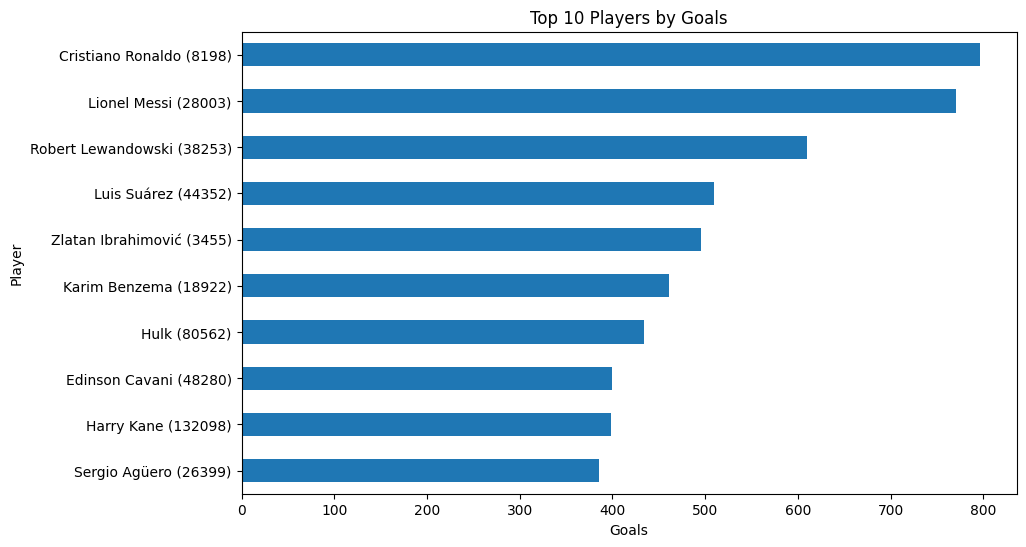

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

top_goals.sort_values().plot(kind="barh")

plt.title("Top 10 Players by Goals")
plt.xlabel("Goals")
plt.ylabel("Player")

plt.show()

## Top 10 Players by Assists

In [ ]:
top_assists = (
    player_performance.groupby("player_name")["assists"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_assists

,assists
player_name,
Lionel Messi (28003),368
Thomas Müller (58358),281
Ángel Di María (45320),278
Luis Suárez (44352),277
Ryan Giggs (3406),269
Dušan Tadić (36139),267
Kevin De Bruyne (88755),261
Cristiano Ronaldo (8198),257
Hulk (80562),231


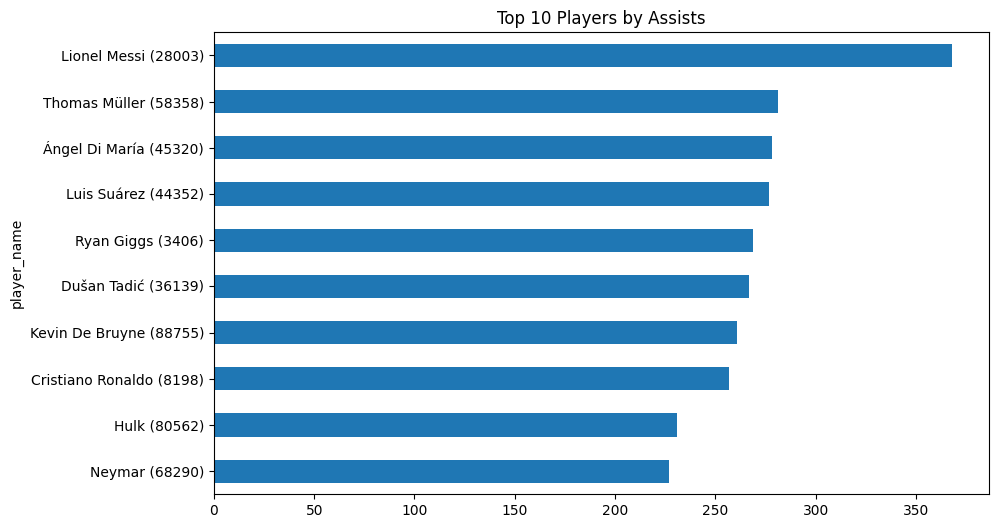

In [ ]:
plt.figure(figsize=(10,6))

top_assists.sort_values().plot(kind="barh")

plt.title("Top 10 Players by Assists")

plt.show()

In [ ]:
top_minutes = (
    player_performance.groupby("player_name")["minutes_played"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_minutes

,minutes_played
player_name,
Fábio (22415),111958.0
Gianluigi Buffon (5023),87251.0
Pepe Reina (7825),85606.0
Iker Casillas (3979),79357.0
Weverton (69400),78164.0
David James (3646),77935.0
Manuel Neuer (17259),74226.0
Edwin van der Sar (3516),73681.0
Shusaku Nishikawa (81787),73631.0


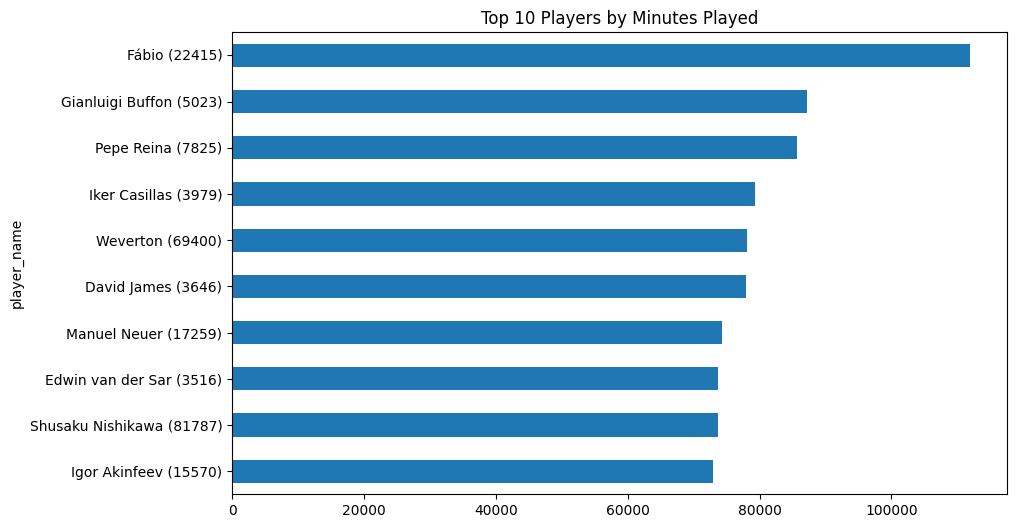

In [ ]:
plt.figure(figsize=(10,6))

top_minutes.sort_values().plot(kind="barh")

plt.title("Top 10 Players by Minutes Played")

plt.show()

In [ ]:
top_market = (
    player_performance.groupby("player_name")["market_value"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

top_market

,market_value
player_name,
Lamine Yamal (937958),200000000.0
Jude Bellingham (581678),180000000.0
Kylian Mbappé (342229),180000000.0
Erling Haaland (418560),180000000.0
Vinicius Junior (371998),170000000.0
Bukayo Saka (433177),150000000.0
Pedri (683840),140000000.0
Florian Wirtz (598577),140000000.0
Jamal Musiala (580195),140000000.0


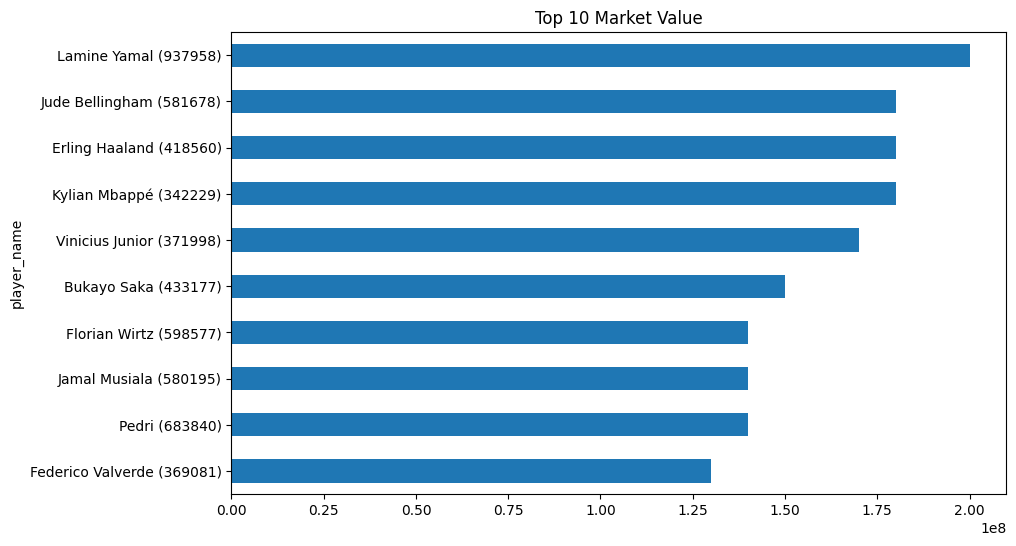

In [ ]:
plt.figure(figsize=(10,6))

top_market.sort_values().plot(kind="barh")

plt.title("Top 10 Market Value")

plt.show()

In [ ]:
top_injuries = (
    player_performance.groupby("player_name")["total_injuries"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

top_injuries

,total_injuries
player_name,
Cheick Diabaté (78082),15.0
Chicharito (50935),15.0
Chico Ofoedu (241693),15.0
İbrahim Yattara (6917),15.0
İlhan Mansız (6875),15.0
İlkay Gündoğan (53622),15.0
İrfan Can Kahveci (216603),15.0
Aaron Cresswell (92571),15.0
Charles Aránguiz (89701),15.0


In [ ]:
club_goals = (
    player_performance.groupby("team_name")["goals"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

club_goals

,goals
team_name,
Real Madrid,3427.0
Arsenal FC,3290.0
FC Barcelona,3190.0
Manchester United,3171.0
Bayern Munich,3095.0
Celtic FC,2844.0
Chelsea FC,2840.0
Rangers FC,2781.0
Manchester City,2709.0


In [ ]:
competition_goals = (
    player_performance.groupby("competition_name_x")["goals"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

competition_goals

,goals
competition_name_x,
Championship,31289.0
Premier League,29896.0
League One,29544.0
Bundesliga,27768.0
LaLiga,24197.0
Serie A,22713.0
Serie B,22461.0
League Two,21204.0
2ª División,20520.0


In [ ]:
player_performance["main_position"].value_counts()

,count
main_position,
Defender,605521
Midfield,560564
Attack,498019
Goalkeeper,197866


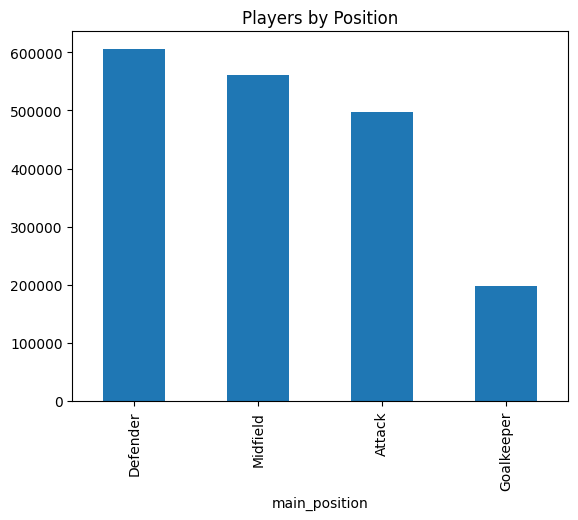

In [ ]:
player_performance["main_position"].value_counts().plot(
    kind="bar"
)

plt.title("Players by Position")

plt.show()

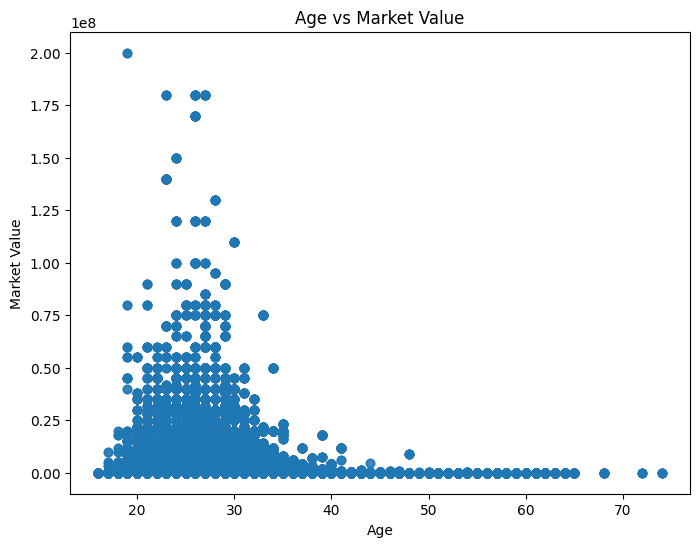

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    player_performance["age"],
    player_performance["market_value"],
    alpha=0.2
)

plt.xlabel("Age")

plt.ylabel("Market Value")

plt.title("Age vs Market Value")

plt.show()

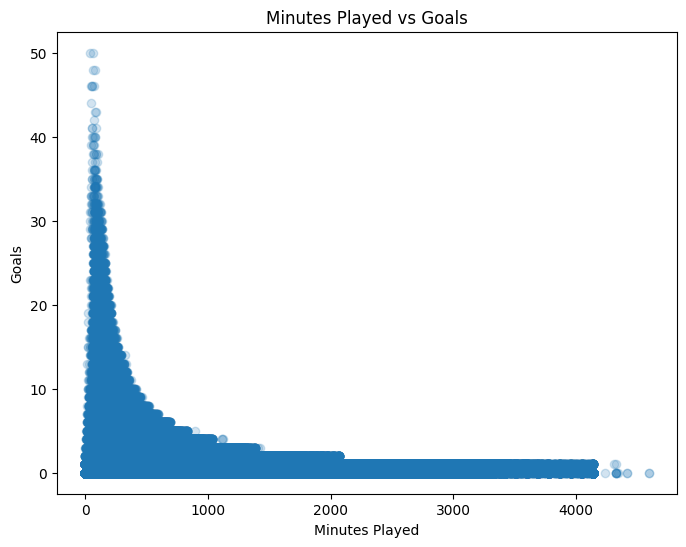

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    player_performance["minutes_played"],
    player_performance["goals"],
    alpha=0.2
)

plt.xlabel("Minutes Played")

plt.ylabel("Goals")

plt.title("Minutes Played vs Goals")

plt.show()

In [ ]:
player_performance.to_csv("sports_analysis_dataset.csv", index=False)

In [ ]:
from google.colab import files

files.download("sports_analysis_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files



files.download("teams_clean.csv")

files.download("injuries_clean.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

players = pd.read_csv("players_clean.csv")
print(players.shape)

(91154, 14)


In [ ]:
print("Dataset Shape:", player_performance.shape)

print("\nNumber of Players:", player_performance['player_id'].nunique())

print("Number of Teams:", player_performance['team_name'].nunique())

print("Number of Competitions:", player_performance['competition_name_x'].nunique())

print("Average Age:", round(player_performance['age'].mean(), 1))

print("Average Height:", round(player_performance['height'].mean(), 1))

print("Total Goals:", int(player_performance['goals'].sum()))

print("Total Assists:", int(player_performance['assists'].sum()))

Dataset Shape: (1861970, 46)

Number of Players: 87206
Number of Teams: 15338
Number of Competitions: 1987
Average Age: 34.4
Average Height: 181.7
Total Goals: 1641840
Total Assists: 832083


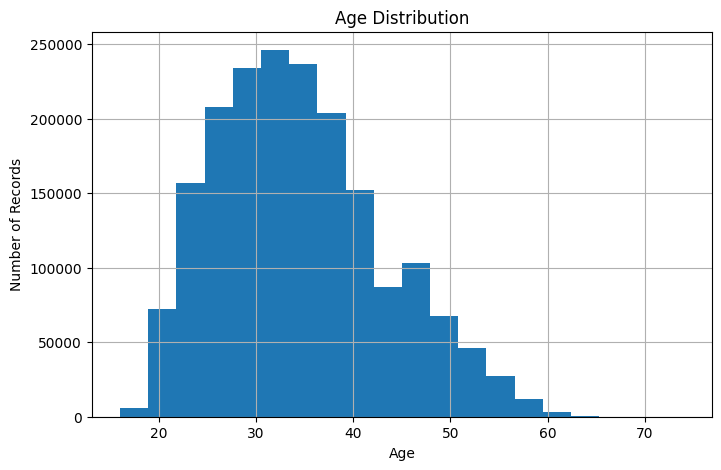

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

player_performance['age'].hist(bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Records")

plt.show()

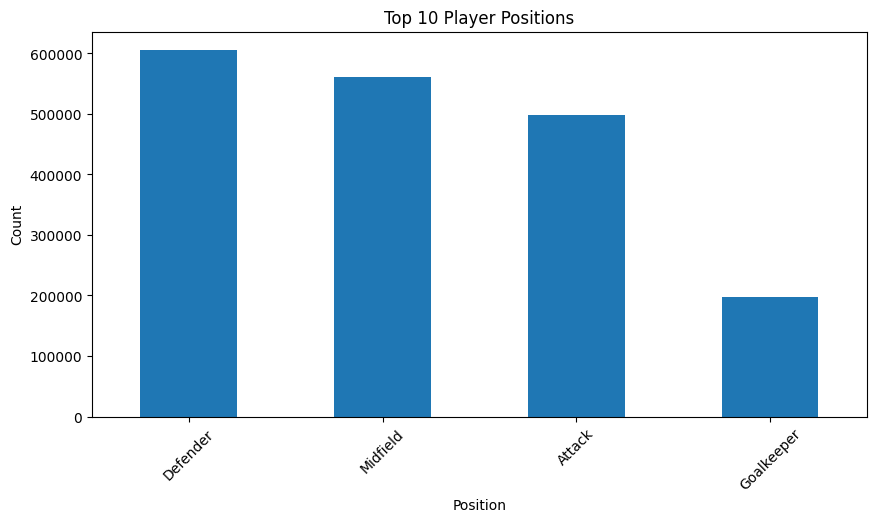

In [ ]:
top_positions = player_performance['main_position'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_positions.plot(kind='bar')

plt.title("Top 10 Player Positions")
plt.xlabel("Position")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

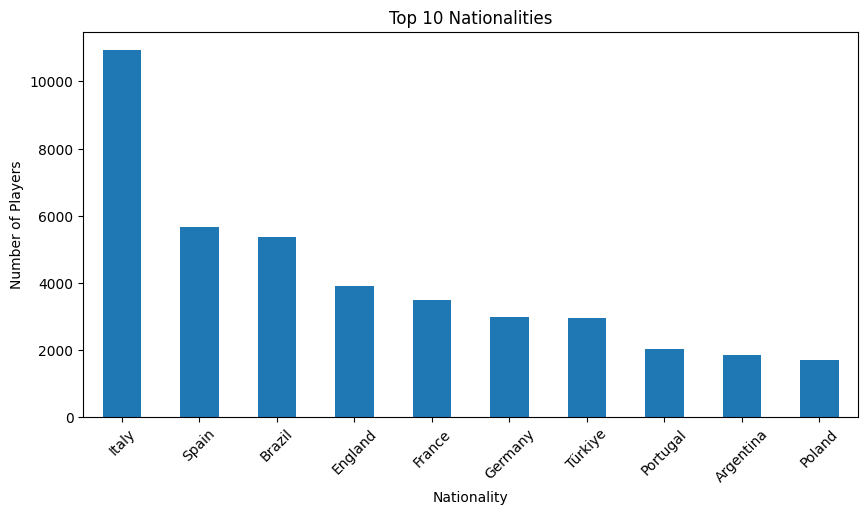

In [ ]:
top_countries = (
    player_performance
    .drop_duplicates(subset='player_id')['citizenship']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Nationalities")
plt.xlabel("Nationality")
plt.ylabel("Number of Players")
plt.xticks(rotation=45)
plt.show()

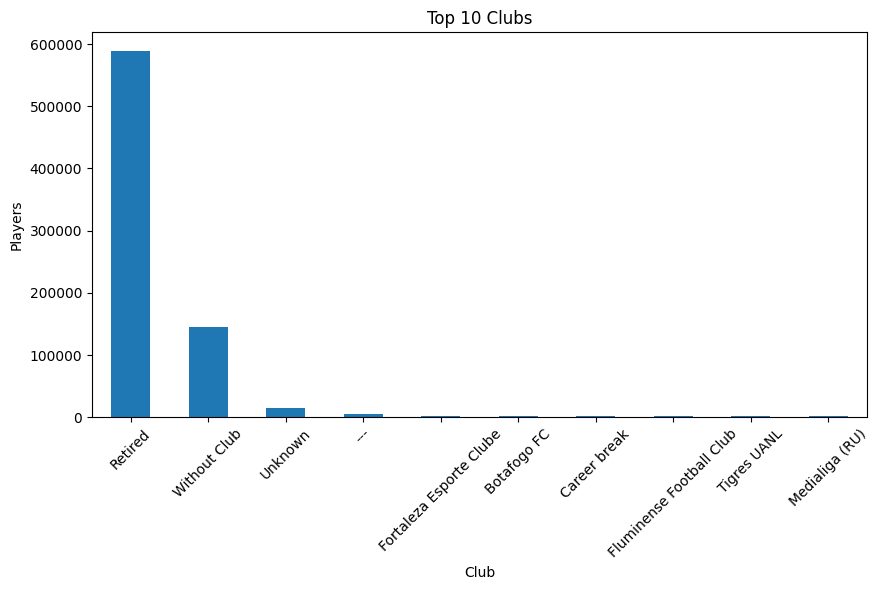

In [ ]:
top_clubs = (
    player_performance['current_club_name']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))
top_clubs.plot(kind='bar')
plt.title("Top 10 Clubs")
plt.xlabel("Club")
plt.ylabel("Players")
plt.xticks(rotation=45)
plt.show()

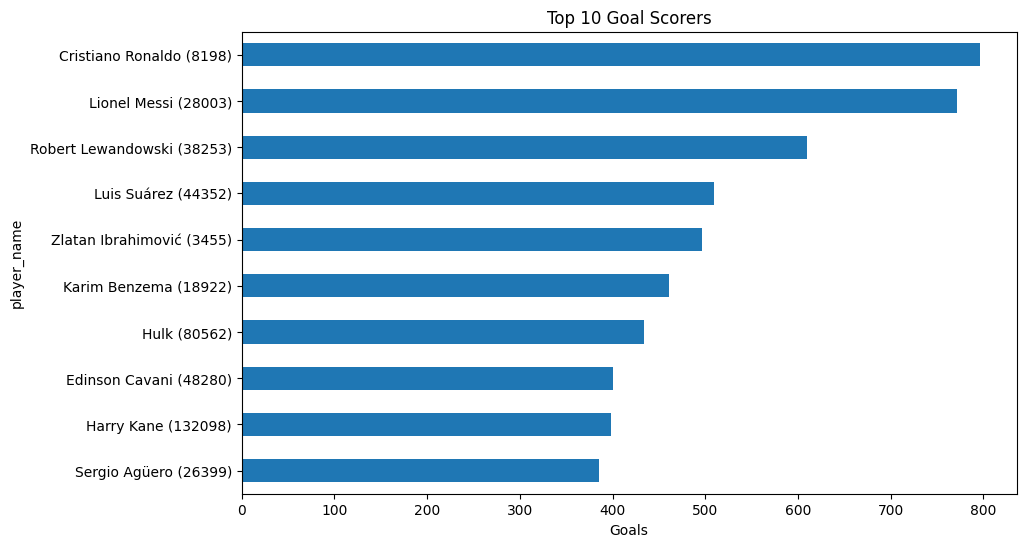

In [ ]:
top_scorers = (
    player_performance
    .groupby('player_name')['goals']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_scorers.plot(kind='barh')
plt.title("Top 10 Goal Scorers")
plt.xlabel("Goals")
plt.gca().invert_yaxis()
plt.show()

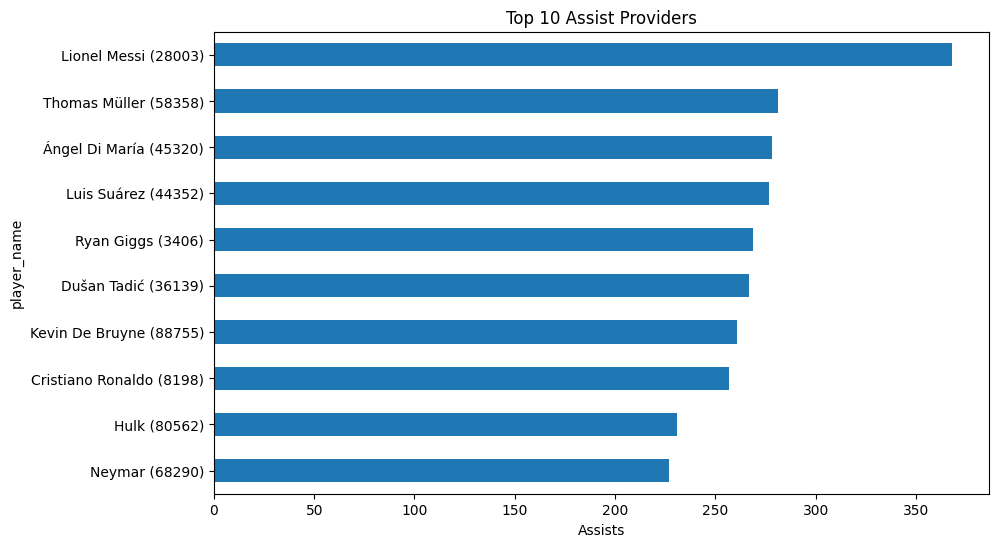

In [ ]:
top_assists = (
    player_performance
    .groupby('player_name')['assists']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_assists.plot(kind='barh')
plt.title("Top 10 Assist Providers")
plt.xlabel("Assists")
plt.gca().invert_yaxis()
plt.show()

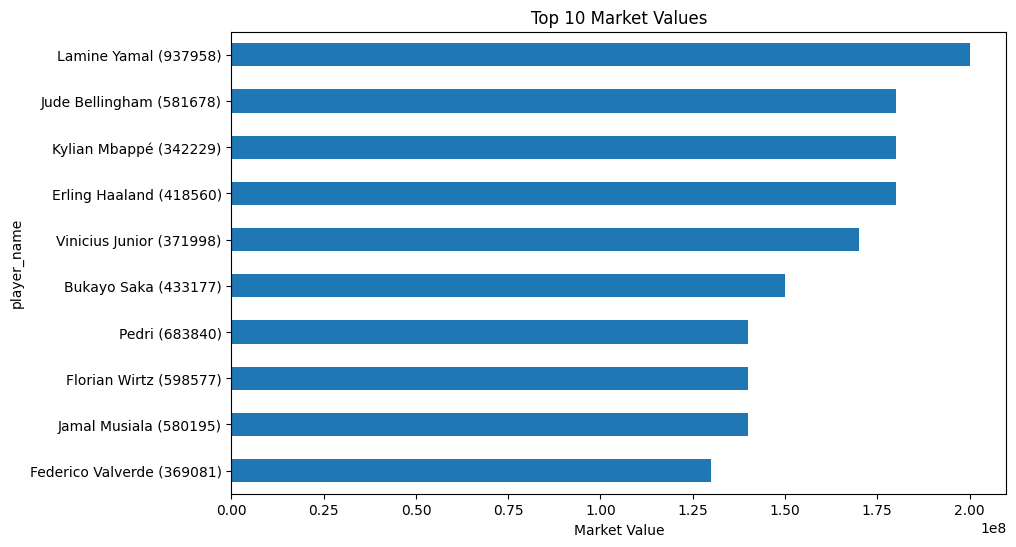

In [ ]:
top_value = (
    player_performance
    .groupby('player_name')['market_value']
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_value.plot(kind='barh')
plt.title("Top 10 Market Values")
plt.xlabel("Market Value")
plt.gca().invert_yaxis()
plt.show()

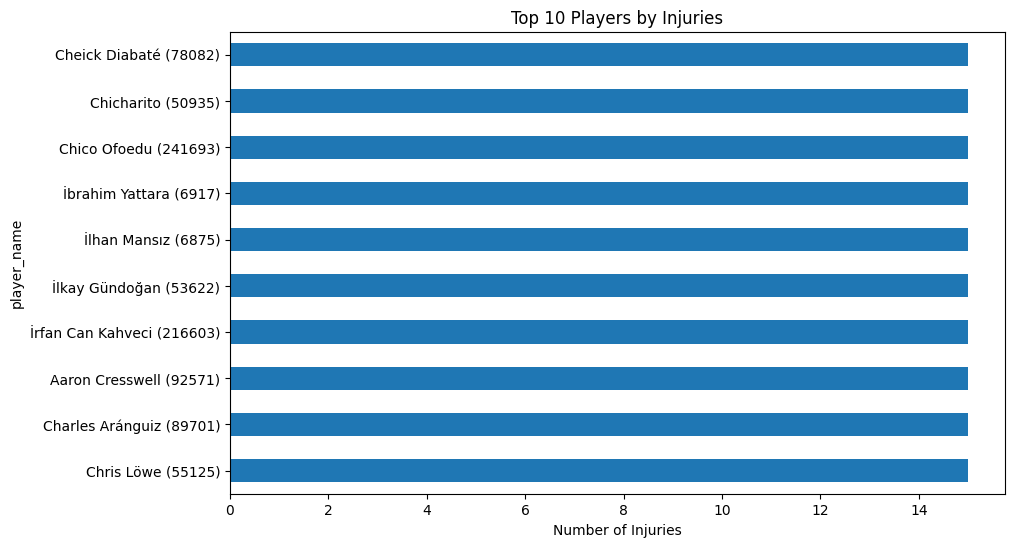

In [ ]:
top_injuries = (
    player_performance
    .groupby('player_name')['total_injuries']
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_injuries.plot(kind='barh')
plt.title("Top 10 Players by Injuries")
plt.xlabel("Number of Injuries")
plt.gca().invert_yaxis()
plt.show()

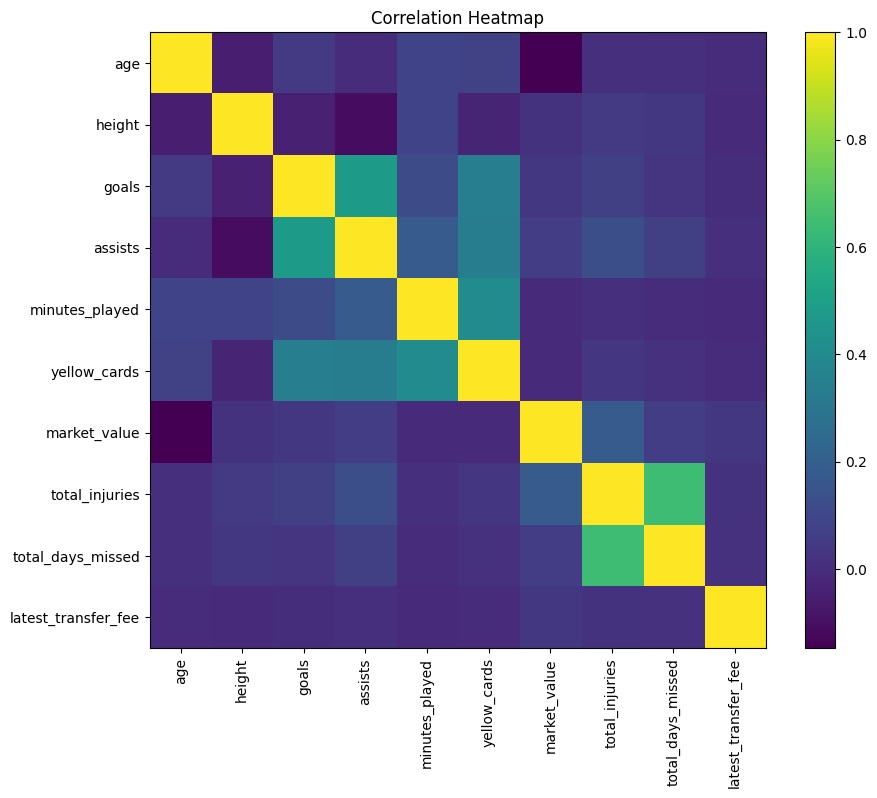

In [ ]:
import matplotlib.pyplot as plt

numeric_cols = [
    'age',
    'height',
    'goals',
    'assists',
    'minutes_played',
    'yellow_cards',
    'market_value',
    'total_injuries',
    'total_days_missed',
    'latest_transfer_fee'
]

corr = player_performance[numeric_cols].corr()

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
player_performance.describe()

,player_id,height,current_club_id,age,team_id,nb_in_group,nb_on_pitch,goals,assists,own_goals,...,clean_sheets,club_id,season_id,market_value,total_injuries,total_days_missed,total_games_missed,total_transfers,latest_market_value,latest_transfer_fee
count,1.861970e+06,1.861970e+06,1.861970e+06,1.861970e+06,1.861970e+06,1.861970e+06,1.861970e+06,1.861970e+06,1.861970e+06,1.861970e+06,...,1.861970e+06,672431.000000,672431.000000,1.861970e+06,1.861970e+06,1.861970e+06,1.861970e+06,1.861970e+06,1.861970e+06,1.861970e+06
mean,2.912578e+05,1.816710e+02,1.266342e+04,3.443995e+01,1.068940e+04,9.927850e+00,8.153631e+00,8.817758e-01,4.468831e-01,1.533752e-02,...,1.917738e-01,10550.832105,2013.235609,8.513617e+05,2.784513e+00,1.299420e+02,1.793605e+01,1.135355e+01,5.394271e+03,7.362501e+03
std,2.911714e+05,6.387585e+00,2.485343e+04,8.639900e+00,1.768354e+04,1.083972e+01,9.859961e+00,2.210607e+00,1.246789e+00,1.301088e-01,...,1.206723e+00,19594.304833,7.784778,4.747812e+06,4.083253e+00,2.239653e+02,2.881935e+01,5.823133e+00,6.513535e+04,1.216861e+05
min,1.000000e+00,1.457583e+02,1.000000e+00,1.600000e+01,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,1.000000,2000.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.573400e+04,1.780000e+02,1.230000e+02,2.800000e+01,8.000000e+02,2.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,677.000000,2006.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,0.000000e+00,0.000000e+00
50%,1.897630e+05,1.815908e+02,6.810000e+02,3.400000e+01,3.062000e+03,4.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2581.000000,2014.000000,0.000000e+00,1.000000e+00,2.800000e+01,4.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00
75%,4.470520e+05,1.860000e+02,1.066300e+04,4.000000e+01,1.144900e+04,1.600000e+01,1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,9638.000000,2021.000000,2.500000e+05,4.000000e+00,1.910000e+02,2.600000e+01,1.500000e+01,0.000000e+00,0.000000e+00
max,1.453181e+06,2.100000e+02,1.345530e+05,7.400000e+01,1.345500e+05,5.100000e+01,5.100000e+01,5.000000e+01,2.900000e+01,9.000000e+00,...,2.900000e+01,133273.000000,2025.000000,2.000000e+08,1.500000e+01,1.159700e+04,3.640000e+02,5.300000e+01,5.000000e+06,9.500000e+06


In [ ]:
player_performance['main_position'].value_counts()

,count
main_position,
Defender,605521
Midfield,560564
Attack,498019
Goalkeeper,197866


In [ ]:
player_performance['competition_name_x'].value_counts().head(15)

,count
competition_name_x,
FA Cup,40465
Italy Cup,30386
Coupe de France,29604
Copa del Rey,28750
Türkiye Kupasi,23562
League Cup,22120
DFB-Pokal,22101
Copa do Brasil,19643
EFL Trophy,19308


In [ ]:
player_performance['country_name'].value_counts().head(15)

,count
country_name,
Italy,86028
England,73031
Brazil,46351
France,42236
Germany,41935
Spain,38140
United States,30922
Türkiye,26246
Mexico,23393


In [ ]:
player_performance.to_csv(
    "football_analysis_final.csv",
    index=False
)

In [ ]:
from google.colab import files
files.download("football_analysis_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>